In [1]:
# 1.Data Cleaning
# 2.Eda
# 3.Text Preprocessing
# 4.Model Building
# 5.Model Evaluation
# 6.Improvement
# 7.Website
# 8.Deploy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("spam.csv",encoding='latin-1')

In [4]:
df.shape

(5572, 5)

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.drop(df.iloc[:,2:5],axis=1,inplace=True)

In [7]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.isnull().sum()

v1    0
v2    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(403)

In [21]:
df.drop_duplicates(df,inplace=True)

In [22]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.rename(columns={'v1':'target','v2':'message'},inplace=True)

In [16]:
df["target"].replace({'ham':0,'spam':1},inplace=True)

C:\Users\prath\AppData\Local\Temp\ipykernel_7108\3512843281.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["target"].replace({'ham':0,'spam':1},inplace=True)
C:\Users\prath\AppData\Local\Temp\ipykernel_7108\3512843281.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["target"].replace({

In [17]:
df.head()

,target,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
df.iloc[:,-1][200]

'I sent you  &lt;#&gt;  bucks'

In [19]:
df["target"]=df["target"].astype(int)

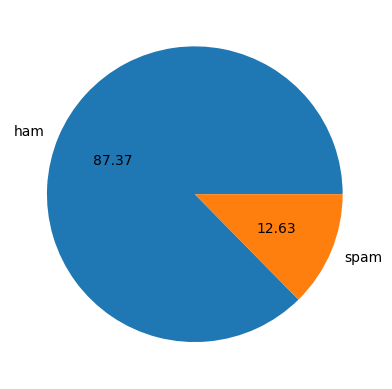

In [33]:
plt.pie(df["target"].value_counts(),labels=['ham','spam'],autopct='%.2f')
plt.show()

In [34]:
#Around 87% is ham data.
# 12% data is spam data.
#Data is imbalanced.

In [36]:
df["message_length"]=df["message"].apply(len)

In [37]:
df["message_length"]

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: message_length, Length: 5169, dtype: int64

In [55]:
df.rename(columns={'message_length':'num_char'},inplace=True)

In [56]:
import nltk


In [57]:
df["word_length"]=df["message"].apply(lambda x:len(nltk.word_tokenize(x)))

In [58]:
df["sent_length"]=df["message"].apply(lambda x:len(nltk.sent_tokenize(x)))

In [59]:
df["sent_length"]

0       2
1       2
2       2
3       1
4       1
       ..
5567    4
5568    1
5569    2
5570    1
5571    2
Name: sent_length, Length: 5169, dtype: int64

In [60]:
df.describe()

,target,num_char,word_length,sent_length
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [67]:
#ham
df[df["target"]==0][['num_char','word_length','sent_length']].describe()

,num_char,word_length,sent_length
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [69]:
#spam
df[df["target"]==1][['num_char','word_length','sent_length']].describe()

,num_char,word_length,sent_length
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_char', ylabel='Count'>

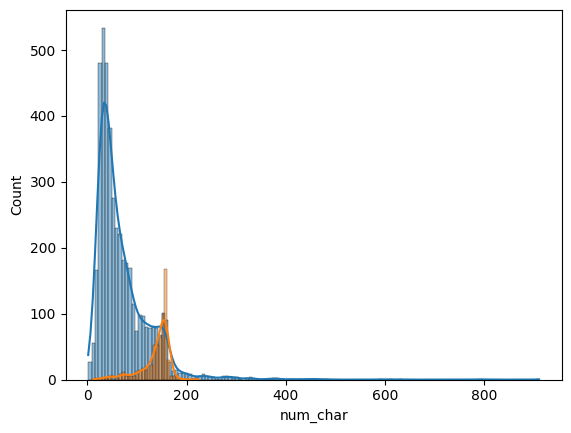

In [64]:
sns.histplot(df[df["target"]==0]["num_char"],kde=True)
sns.histplot(df[df["target"]==1]["num_char"],kde=True)

<Axes: xlabel='word_length', ylabel='Count'>

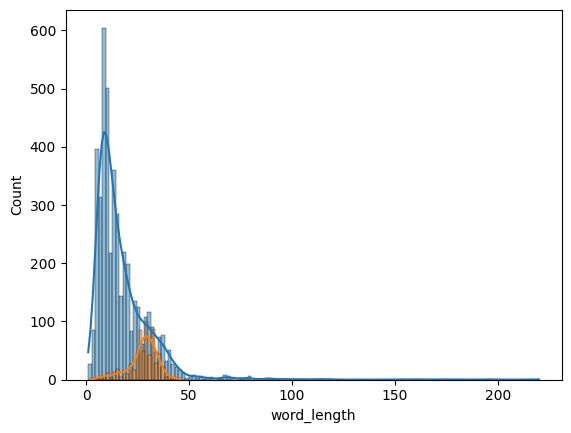

In [70]:
sns.histplot(df[df["target"]==0]["word_length"],kde=True)
sns.histplot(df[df["target"]==1]["word_length"],kde=True)

In [71]:
#Most ham messages are made from less words
#Most spam messages are made from more words 

## Textpreprocessing Steps
* LowerCase
* Tokenization
* Removing Special Characters
* Removing Stopwords and Punctuation
* Stemming

In [88]:
import string
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
ps=PorterStemmer()

In [92]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and (i not in string.punctuation):
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return ' '.join(y)
        
        
            
        
        

In [95]:
df['text_tnf']=df["message"].apply(transform_text)

In [97]:
df["text_tnf"]

0       go jurong point crazi avail bugi n great world...
1                                   ok lar joke wif u oni
2       free entri 2 wkli comp win fa cup final tkt 21...
3                     u dun say earli hor u c alreadi say
4                    nah think goe usf live around though
                              ...                        
5567    2nd time tri 2 contact u pound prize 2 claim e...
5568                                b go esplanad fr home
5569                                    piti mood suggest
5570    guy bitch act like interest buy someth els nex...
5571                                       rofl true name
Name: text_tnf, Length: 5169, dtype: object

In [98]:
from wordcloud import WordCloud

In [114]:
wc=WordCloud(width=100,height=100,min_font_size=10,background_color="White")

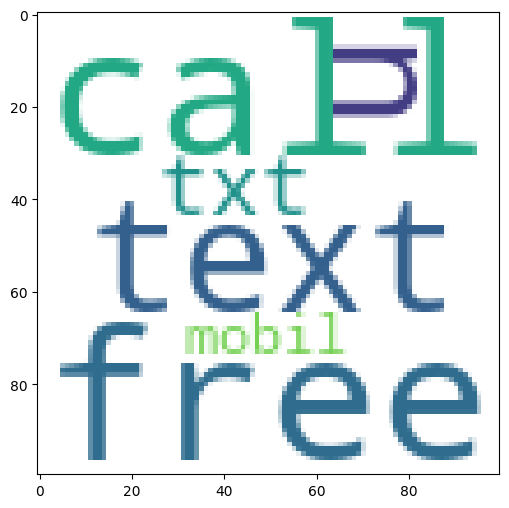

In [119]:
plt.figure(figsize=(12,6))
spam_wc=wc.generate(df[df["target"]==1]['text_tnf'].str.cat(sep=' '))
plt.imshow(spam_wc)

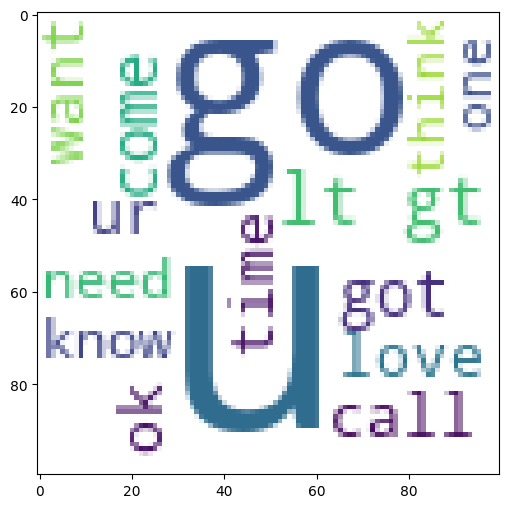

In [121]:
plt.figure(figsize=(12,6))
spam_wc=wc.generate(df[df["target"]==0]['text_tnf'].str.cat(sep=' '))
plt.imshow(spam_wc)

In [170]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix

In [158]:
tfidf=TfidfVectorizer(max_features=3000)
mnb=MultinomialNB()

In [159]:
X=tfidf.fit_transform(df["text_tnf"]).toarray()

In [160]:
X.shape

(5169, 3000)

In [161]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 3000))

In [162]:
y=df["target"].values

In [163]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [165]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=2,test_size=0.2)

In [166]:
mnb.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [167]:
y_pred=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(precision_score(y_test,y_pred))


0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [169]:
import pickle 
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open("model.pkl","wb"))